# Model Comparison

This notebook compares the performance of the trained
Random Forest, XGBoost, and SVR models for crop yield prediction.

The models are evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The trained models are loaded from the models folder.
No model is retrained in this notebook.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")


Libraries imported successfully.


In [34]:
evaluation_path = r"C:\Crop Yield Prediction\outputs\model_evaluation_results.csv"

evaluation_df = pd.read_csv(evaluation_path)

print("Model evaluation results loaded successfully.")

display(evaluation_df)

Model evaluation results loaded successfully.


,Model,MAE,MSE,RMSE,R²
0,Random Forest,11.588271,23237.085144,152.437151,0.967113
1,XGBoost,10.303999,15721.064408,125.383669,0.977750
2,SVR,60.807512,553774.217331,744.160075,0.216259


In [35]:
print("Columns available in File 08 results:")

print(
    evaluation_df.columns.tolist()
)

Columns available in File 08 results:
['Model', 'MAE', 'MSE', 'RMSE', 'R²']


In [36]:
# Make a copy of the File 08 results
comparison_df = evaluation_df.copy()

# Find the R2 column used in File 08
r2_column = None

for column in comparison_df.columns:
    if column.strip().lower() in [
        "r2",
        "r²",
        "r2 score",
        "r² score",
        "r_squared",
        "r-squared"
    ]:
        r2_column = column
        break

# Rename it to R2 for File 09
if r2_column is not None:
    comparison_df = comparison_df.rename(
        columns={r2_column: "R2"}
    )
else:
    print("R2 column was not found.")
    print("Available columns:")
    print(comparison_df.columns.tolist())

# Display comparison table
display(comparison_df)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,11.588271,23237.085144,152.437151,0.967113
1,XGBoost,10.303999,15721.064408,125.383669,0.977750
2,SVR,60.807512,553774.217331,744.160075,0.216259


In [37]:
display(
    comparison_df.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

,Model,MAE,MSE,RMSE,R2
0,Random Forest,11.5883,23237.0851,152.4372,0.9671
1,XGBoost,10.3040,15721.0644,125.3837,0.9778
2,SVR,60.8075,553774.2173,744.1601,0.2163


In [38]:
lowest_mae = comparison_df.loc[
    comparison_df["MAE"].idxmin()
]

lowest_mse = comparison_df.loc[
    comparison_df["MSE"].idxmin()
]

lowest_rmse = comparison_df.loc[
    comparison_df["RMSE"].idxmin()
]

highest_r2 = comparison_df.loc[
    comparison_df["R2"].idxmax()
]

print("Lowest MAE :", lowest_mae["Model"])
print("Lowest MSE :", lowest_mse["Model"])
print("Lowest RMSE:", lowest_rmse["Model"])
print("Highest R² :", highest_r2["Model"])

Lowest MAE : XGBoost
Lowest MSE : XGBoost
Lowest RMSE: XGBoost
Highest R² : XGBoost


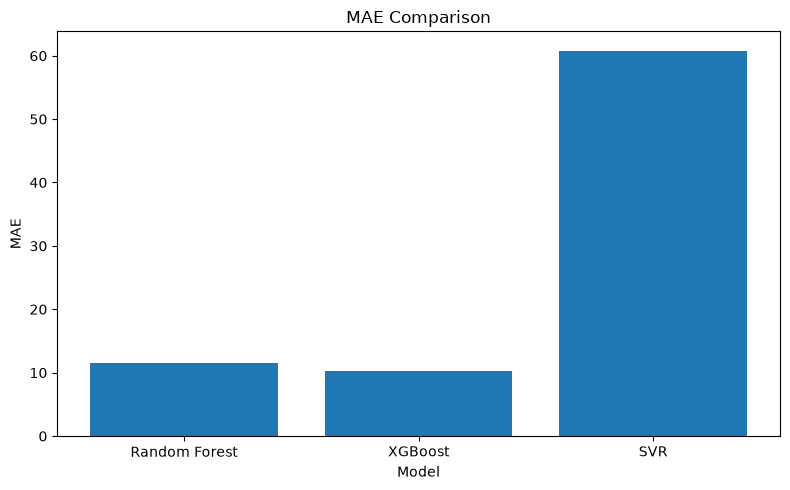

In [39]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("MAE Comparison")

plt.tight_layout()
plt.show()

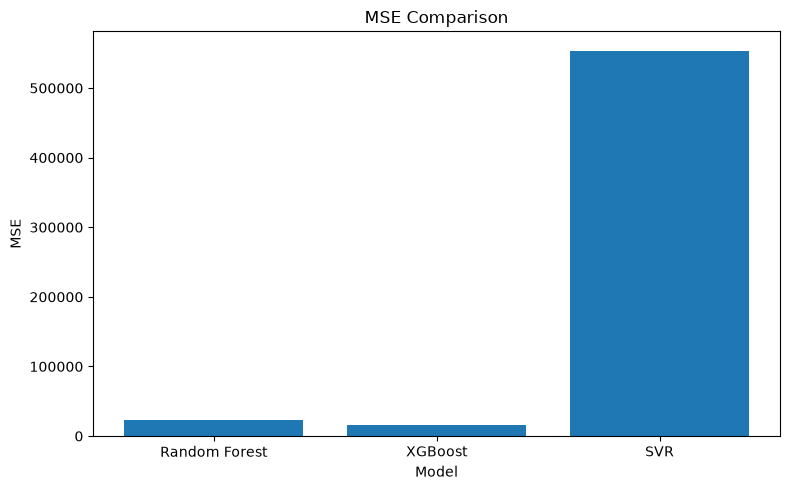

In [40]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MSE"]
)

plt.xlabel("Model")
plt.ylabel("MSE")
plt.title("MSE Comparison")

plt.tight_layout()
plt.show()

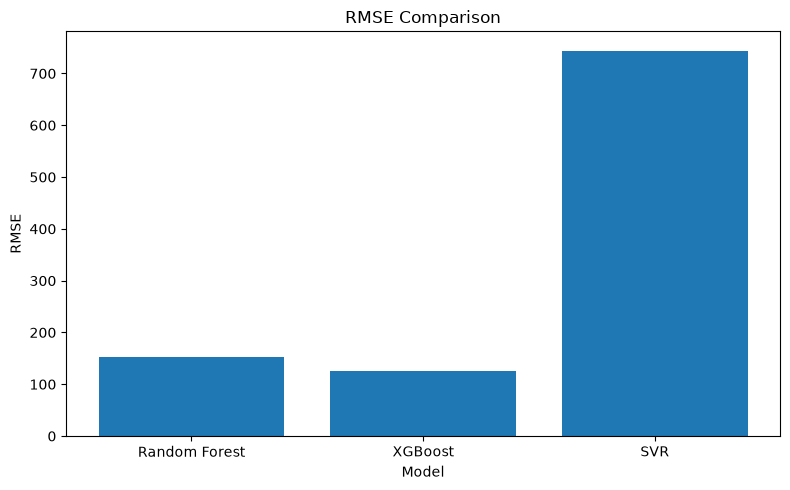

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.tight_layout()
plt.show()

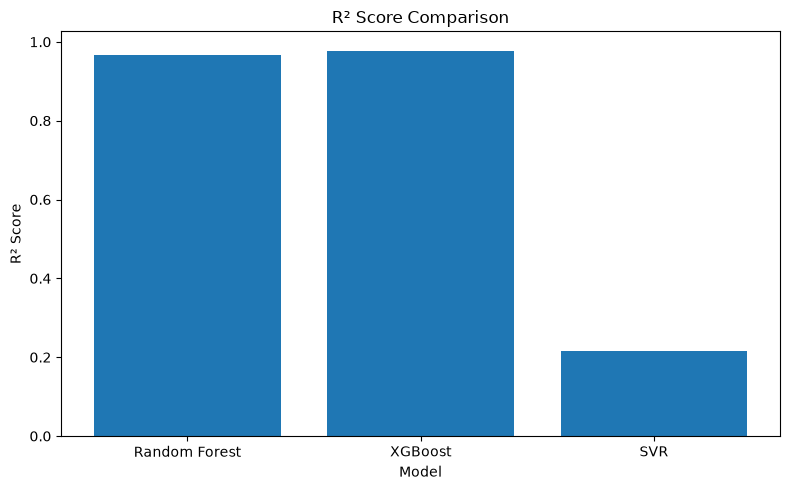

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.tight_layout()
plt.show()

In [43]:
comparison_path = r"C:\Crop Yield Prediction\outputs\model_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("Model comparison saved successfully.")
print(comparison_path)

Model comparison saved successfully.
C:\Crop Yield Prediction\outputs\model_comparison.csv


In [44]:
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

for _, row in comparison_df.iterrows():

    print("\n" + row["Model"])
    print("-" * 40)

    print(f"MAE  : {row['MAE']:.4f}")
    print(f"MSE  : {row['MSE']:.4f}")
    print(f"RMSE : {row['RMSE']:.4f}")
    print(f"R²   : {row['R2']:.4f}")

MODEL COMPARISON SUMMARY

Random Forest
----------------------------------------
MAE  : 11.5883
MSE  : 23237.0851
RMSE : 152.4372
R²   : 0.9671

XGBoost
----------------------------------------
MAE  : 10.3040
MSE  : 15721.0644
RMSE : 125.3837
R²   : 0.9778

SVR
----------------------------------------
MAE  : 60.8075
MSE  : 553774.2173
RMSE : 744.1601
R²   : 0.2163


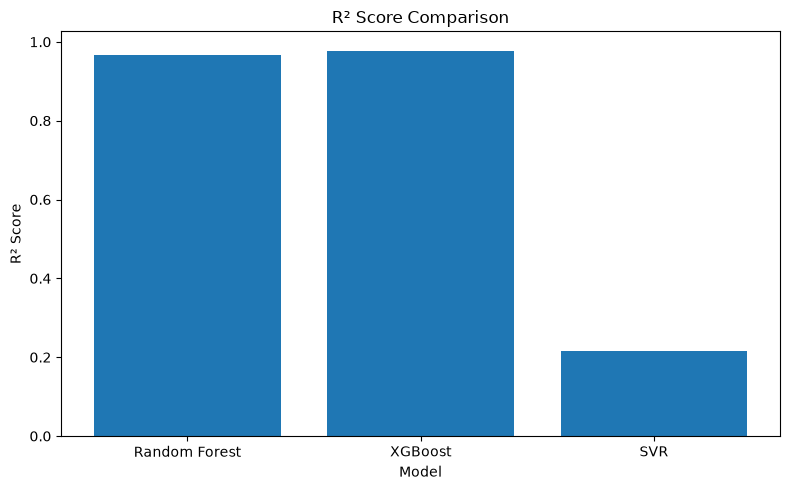

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.tight_layout()
plt.show()

## Model Comparison

The performance of Random Forest, XGBoost, and SVR was compared using
MAE, MSE, RMSE, and R² Score.

MAE, MSE, and RMSE are error measures, where lower values indicate
smaller prediction errors. R² Score measures the proportion of variation
in crop yield explained by the model, where a higher value indicates
better predictive performance.

The comparison results provide a basis for discussing the performance
of the three regression models in the next notebook.